# 2D sampling

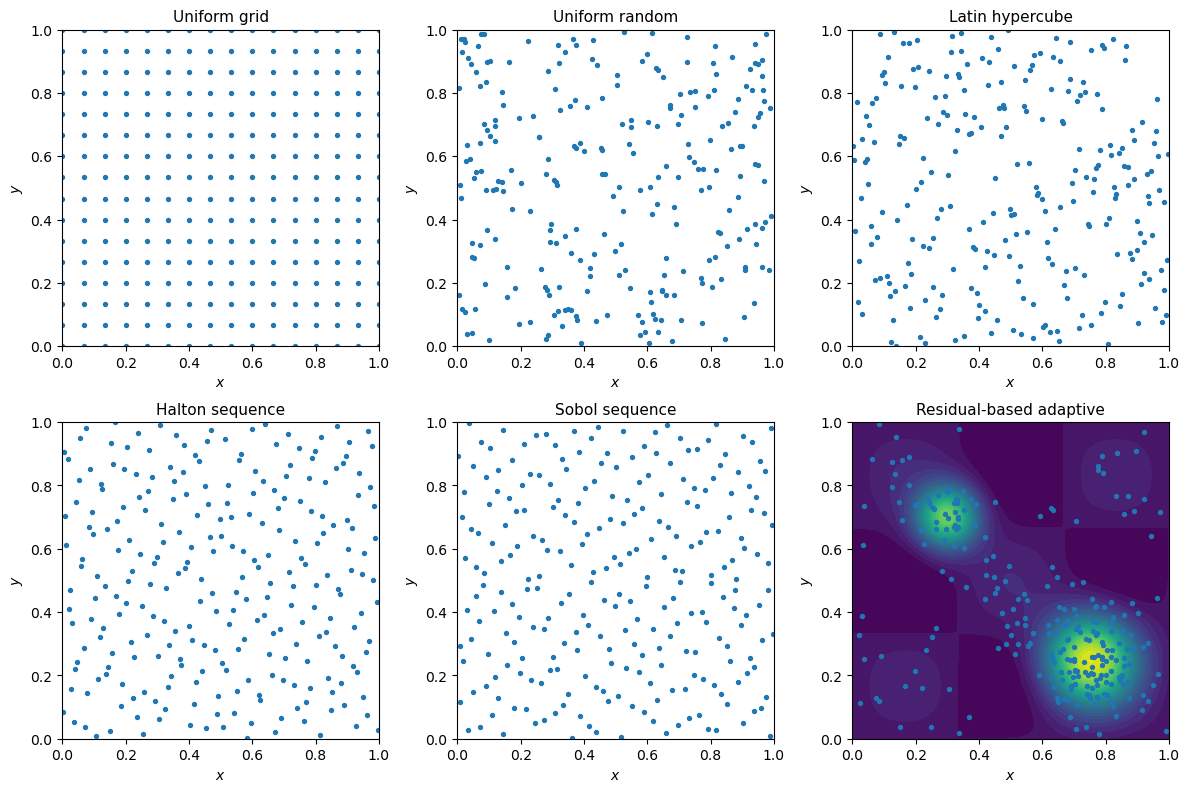

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

# =========================
# Configuration
# =========================
np.random.seed(42)
N = 256
domain = [0.0, 1.0]

# =========================
# Helper: mock residual field
# two high-error regions to mimic wells / interfaces / singular zones
# =========================
def residual_field(x, y):
    r1 = np.exp(-((x - 0.3)**2 + (y - 0.7)**2) / 0.01)
    r2 = 1.2 * np.exp(-((x - 0.75)**2 + (y - 0.25)**2) / 0.02)
    bg = 0.05 + 0.1 * np.sin(3 * np.pi * x) * np.sin(3 * np.pi * y)
    return np.maximum(r1 + r2 + bg, 1e-8)

# =========================
# 1. Uniform grid
# =========================
m = int(np.sqrt(N))
gx = np.linspace(domain[0], domain[1], m)
gy = np.linspace(domain[0], domain[1], m)
Xg, Yg = np.meshgrid(gx, gy)
grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])

# =========================
# 2. Uniform random
# =========================
rand_pts = np.random.rand(N, 2)

# =========================
# 3. Latin hypercube
# =========================
lhs_sampler = qmc.LatinHypercube(d=2, seed=42)
lhs_pts = lhs_sampler.random(n=N)

# =========================
# 4. Halton
# =========================
halton_sampler = qmc.Halton(d=2, scramble=True, seed=42)
halton_pts = halton_sampler.random(n=N)

# =========================
# 5. Sobol
# Sobol prefers powers of 2
# =========================
sobol_sampler = qmc.Sobol(d=2, scramble=True, seed=42)
sobol_pts = sobol_sampler.random_base2(m=8)  # 2^8 = 256

# =========================
# 6. Residual-based adaptive sampling (illustrative)
# Sample candidate points, then resample with probability ~ residual
# =========================
Ncand = 5000
cand = np.random.rand(Ncand, 2)
res = residual_field(cand[:, 0], cand[:, 1])
prob = res / np.sum(res)
idx = np.random.choice(np.arange(Ncand), size=N, replace=False, p=prob)
adaptive_pts = cand[idx]

# =========================
# Plot helper
# =========================
def plot_points(ax, pts, title, show_bg=False):
    if show_bg:
        xx = np.linspace(0, 1, 200)
        yy = np.linspace(0, 1, 200)
        XX, YY = np.meshgrid(xx, yy)
        RR = residual_field(XX, YY)
        ax.contourf(XX, YY, RR, levels=30)
    ax.scatter(pts[:, 0], pts[:, 1], s=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

# =========================
# Create figure
# =========================
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

plot_points(axes[0, 0], grid_pts, "Uniform grid")
plot_points(axes[0, 1], rand_pts, "Uniform random")
plot_points(axes[0, 2], lhs_pts, "Latin hypercube")
plot_points(axes[1, 0], halton_pts, "Halton sequence")
plot_points(axes[1, 1], sobol_pts, "Sobol sequence")
plot_points(axes[1, 2], adaptive_pts, "Residual-based adaptive", show_bg=True)
plt.tight_layout()
plt.savefig("fig_sampling_strategies_2D.png", dpi=600)
plt.show()

# 3D sampling

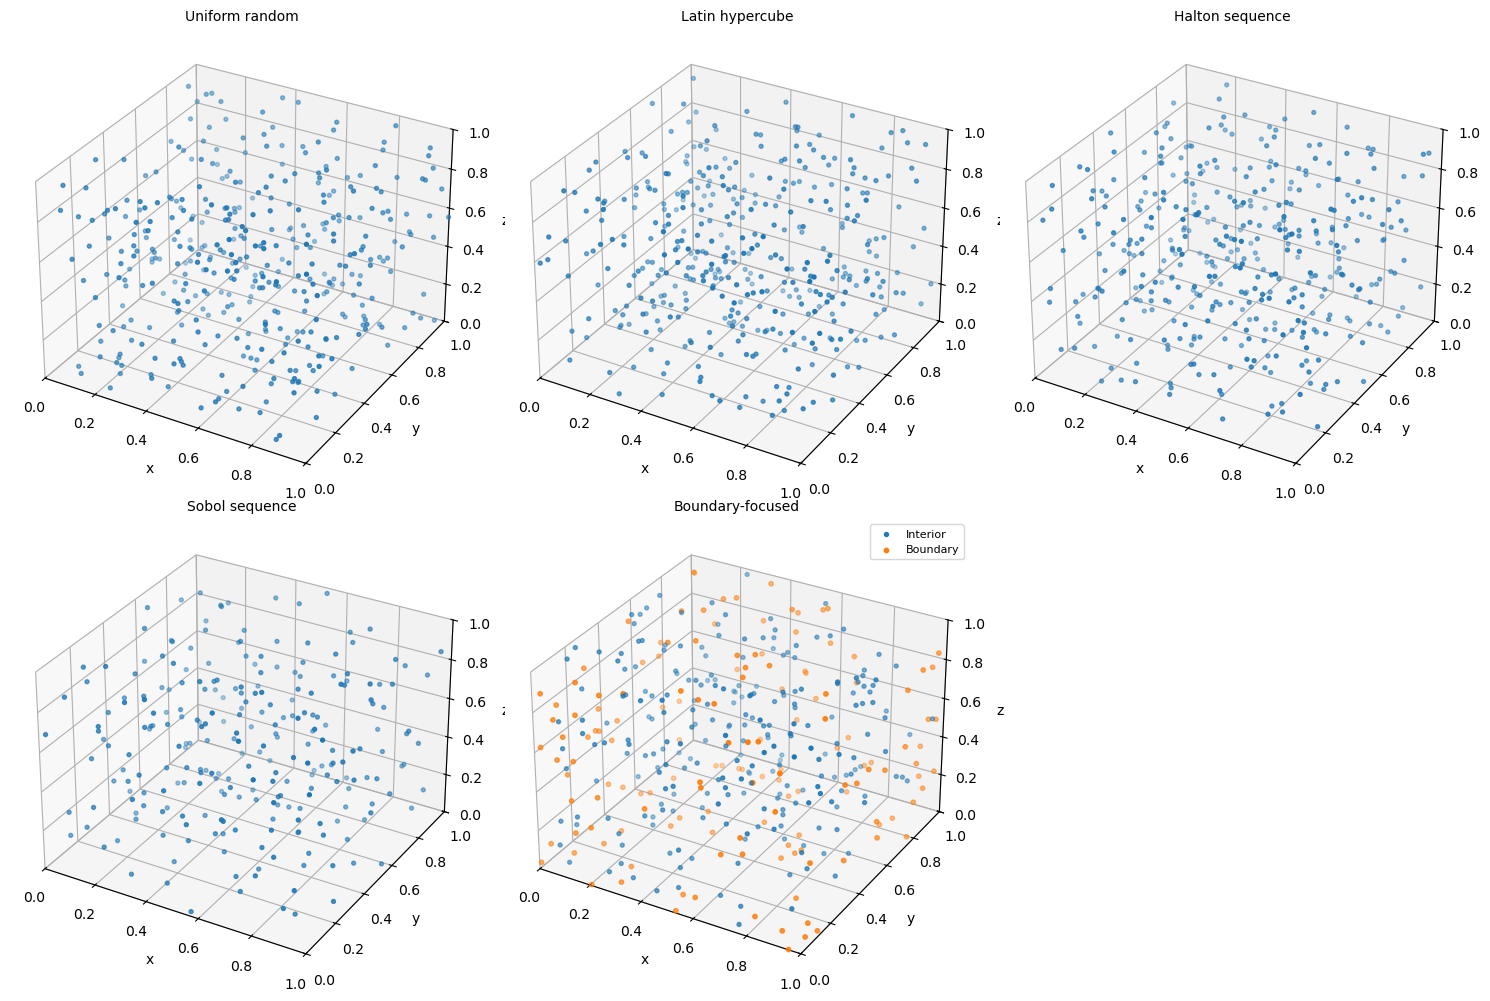

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

np.random.seed(42)
N = 400

# =========================
# 1. Uniform random
# =========================
pts_random = np.random.rand(N, 3)

# =========================
# 2. Latin hypercube
# =========================
lhs_sampler = qmc.LatinHypercube(d=3, seed=42)
pts_lhs = lhs_sampler.random(n=N)

# =========================
# 3. Halton
# =========================
halton_sampler = qmc.Halton(d=3, scramble=True, seed=42)
pts_halton = halton_sampler.random(n=N)

# =========================
# 4. Sobol
# Sobol prefers powers of 2
# =========================
sobol_sampler = qmc.Sobol(d=3, scramble=True, seed=42)
pts_sobol = sobol_sampler.random_base2(m=8)  # 256 points

# =========================
# 5. Boundary-focused sampling in 3D
# Interior + points on cube faces
# =========================
N_interior = 250
N_boundary = 150

interior = np.random.rand(N_interior, 3)
boundary = np.random.rand(N_boundary, 3)

faces = np.random.choice(6, size=N_boundary)
for i, f in enumerate(faces):
    if f == 0:
        boundary[i, 0] = 0.0
    elif f == 1:
        boundary[i, 0] = 1.0
    elif f == 2:
        boundary[i, 1] = 0.0
    elif f == 3:
        boundary[i, 1] = 1.0
    elif f == 4:
        boundary[i, 2] = 0.0
    else:
        boundary[i, 2] = 1.0

pts_boundary = np.vstack([interior, boundary])

# =========================
# Plot helper
# =========================
def plot_3d(ax, pts, title, boundary_mask=None):
    if boundary_mask is None:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=8)
    else:
        ax.scatter(pts[~boundary_mask, 0], pts[~boundary_mask, 1], pts[~boundary_mask, 2], s=8, label='Interior')
        ax.scatter(pts[boundary_mask, 0], pts[boundary_mask, 1], pts[boundary_mask, 2], s=10, label='Boundary')
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)

fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(231, projection='3d')
plot_3d(ax1, pts_random, "Uniform random")

ax2 = fig.add_subplot(232, projection='3d')
plot_3d(ax2, pts_lhs, "Latin hypercube")

ax3 = fig.add_subplot(233, projection='3d')
plot_3d(ax3, pts_halton, "Halton sequence")

ax4 = fig.add_subplot(234, projection='3d')
plot_3d(ax4, pts_sobol, "Sobol sequence")

ax5 = fig.add_subplot(235, projection='3d')
mask_boundary = np.arange(len(pts_boundary)) >= N_interior
plot_3d(ax5, pts_boundary, "Boundary-focused", boundary_mask=mask_boundary)

plt.tight_layout()
plt.savefig("fig_sampling_strategies_3D.png", dpi=600)
plt.show()

## RAD Sampling

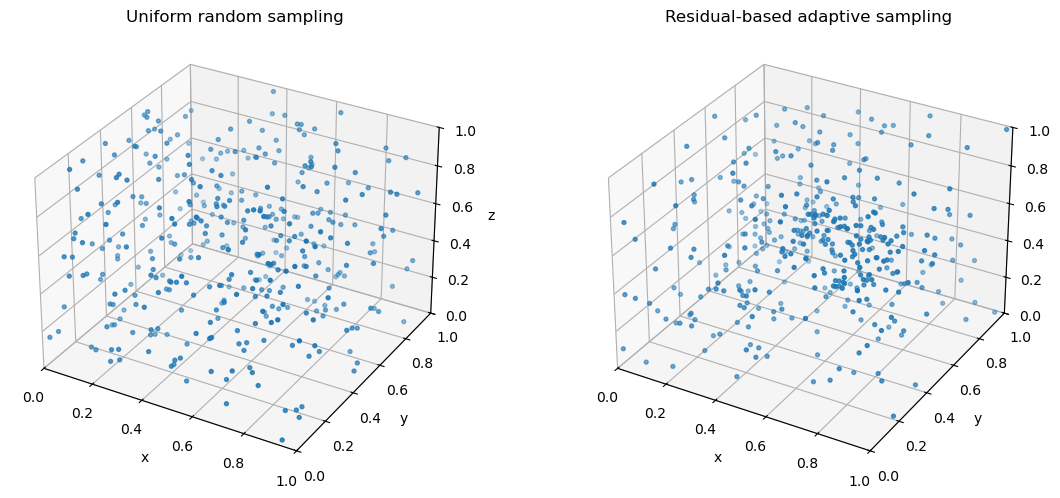

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 400
Ncand = 8000

# =========================
# Mock residual field in 3D
# two localized high-residual regions
# =========================
def residual_field_3d(x, y, z):
    r1 = np.exp(-((x - 0.25)**2 + (y - 0.7)**2 + (z - 0.4)**2) / 0.01)
    r2 = 1.3 * np.exp(-((x - 0.75)**2 + (y - 0.3)**2 + (z - 0.75)**2) / 0.02)
    bg = 0.05 + 0.05 * np.sin(2*np.pi*x) * np.sin(2*np.pi*y) * np.sin(2*np.pi*z)
    return np.maximum(r1 + r2 + bg, 1e-10)

# Candidate pool
cand = np.random.rand(Ncand, 3)
res = residual_field_3d(cand[:, 0], cand[:, 1], cand[:, 2])
prob = res / np.sum(res)

idx = np.random.choice(np.arange(Ncand), size=N, replace=False, p=prob)
pts_adaptive = cand[idx]

# For comparison: uniform random
pts_uniform = np.random.rand(N, 3)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(pts_uniform[:, 0], pts_uniform[:, 1], pts_uniform[:, 2], s=8)
ax1.set_title("Uniform random sampling")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_zlim(0, 1)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(pts_adaptive[:, 0], pts_adaptive[:, 1], pts_adaptive[:, 2], s=8)
ax2.set_title("Residual-based adaptive sampling")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_zlim(0, 1)

plt.tight_layout()
plt.savefig("fig_RAD_sampling_3D.png", dpi=300)
plt.show()